<a href="https://colab.research.google.com/github/KamoTaueatsoala/ML-Projects/blob/main/Irrigation_schedule.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

[0]	train-mae:21.42521	eval-mae:22.17848
[50]	train-mae:1.67147	eval-mae:1.74514


/usr/local/lib/python3.11/dist-packages/xgboost/core.py:158: UserWarning: [01:17:26] WARNING: /workspace/src/learner.cc:740: 
Parameters: { "early_stopping_rounds", "n_estimators" } are not used.

  warnings.warn(smsg, UserWarning)


[100]	train-mae:0.16764	eval-mae:0.20921
[150]	train-mae:0.06951	eval-mae:0.10818
[200]	train-mae:0.06202	eval-mae:0.10173
[250]	train-mae:0.06143	eval-mae:0.10157
[283]	train-mae:0.06130	eval-mae:0.10155

Model Performance for Tomatoes in Loamy Soil:
R² Score: 0.9998
Mean Absolute Error: 0.1015 liters
Root Mean Squared Error: 0.3361 liters
Explained Variance: 0.9998

Zero-Water Performance:
Accuracy: N/A (no zero-water cases)
False Alarms: 0
Missed Needs: 0


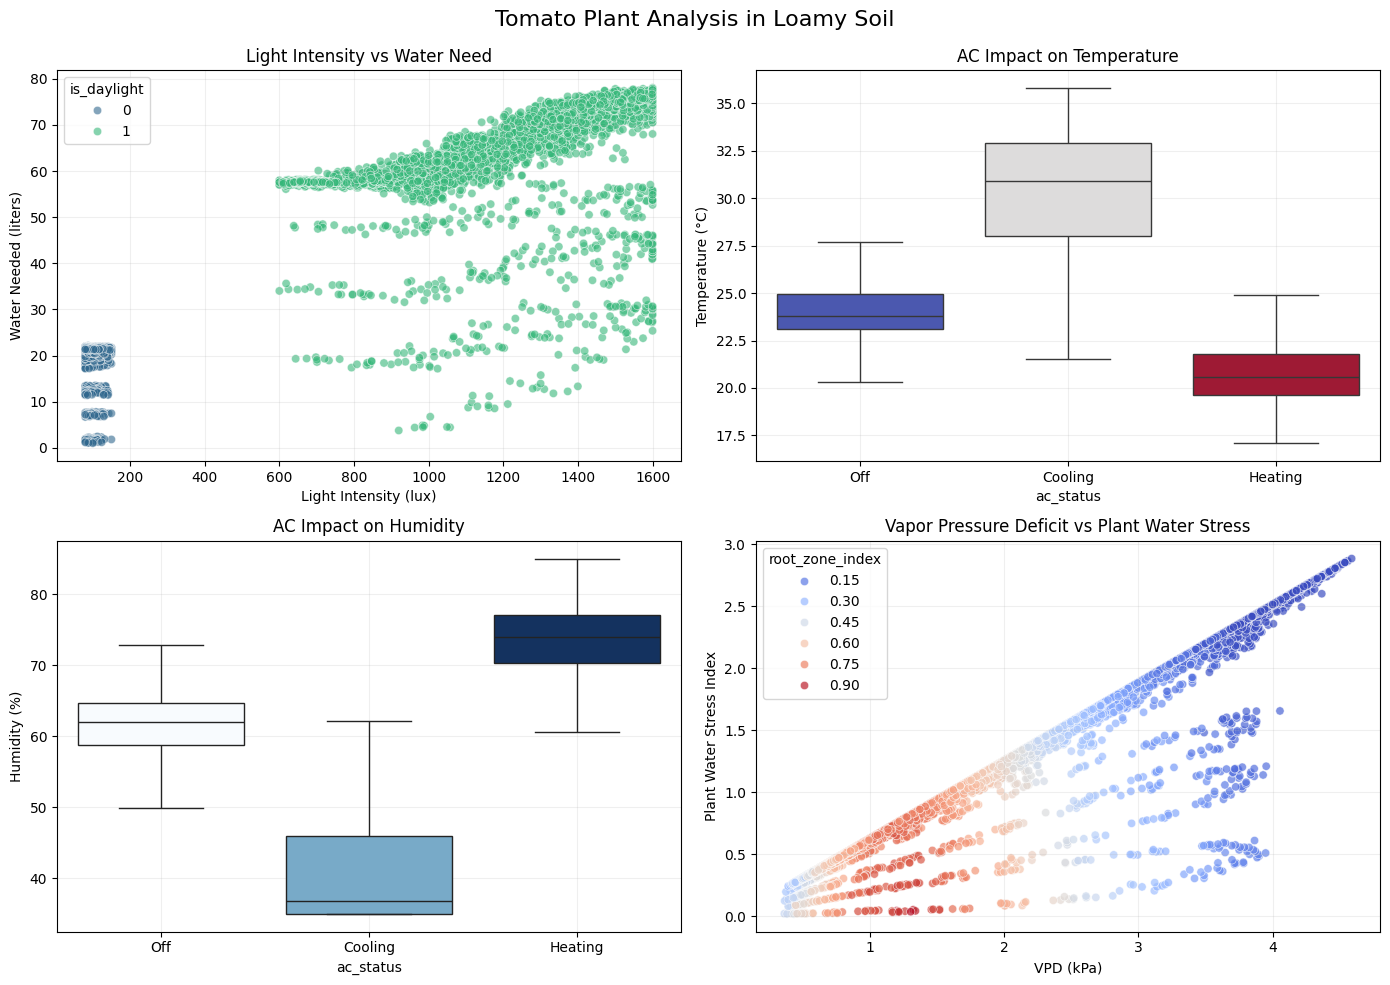

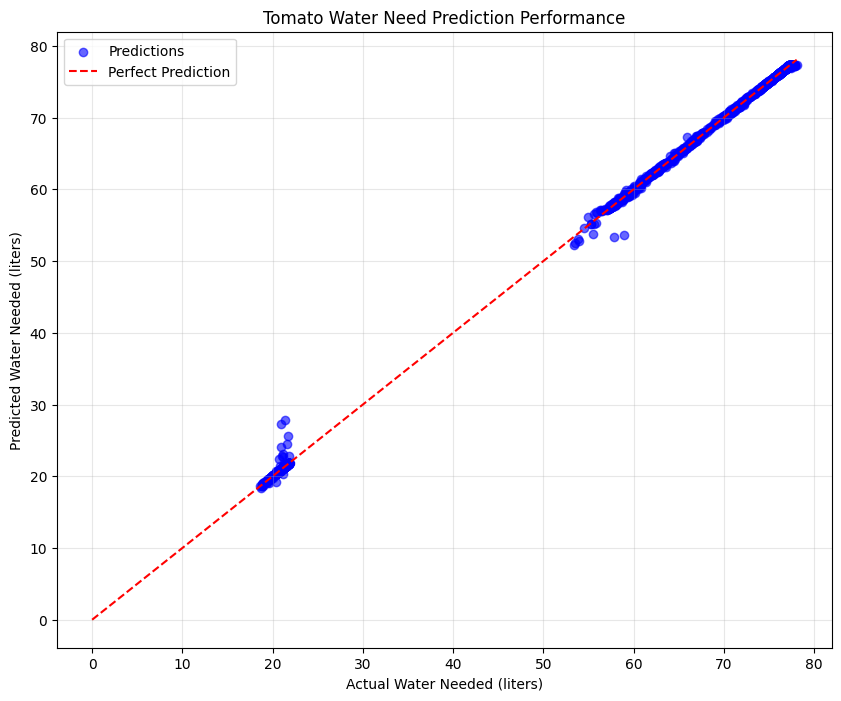

<Figure size 1200x800 with 0 Axes>

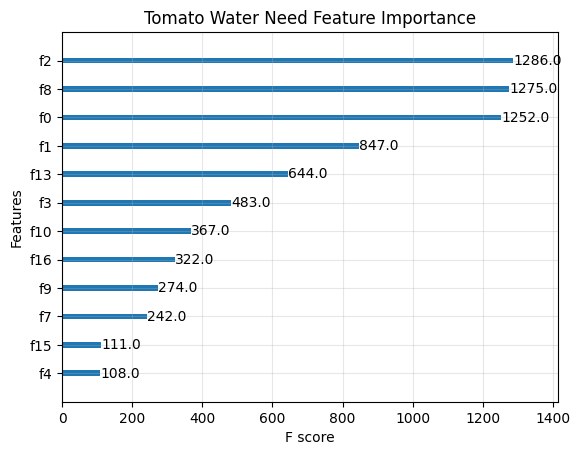

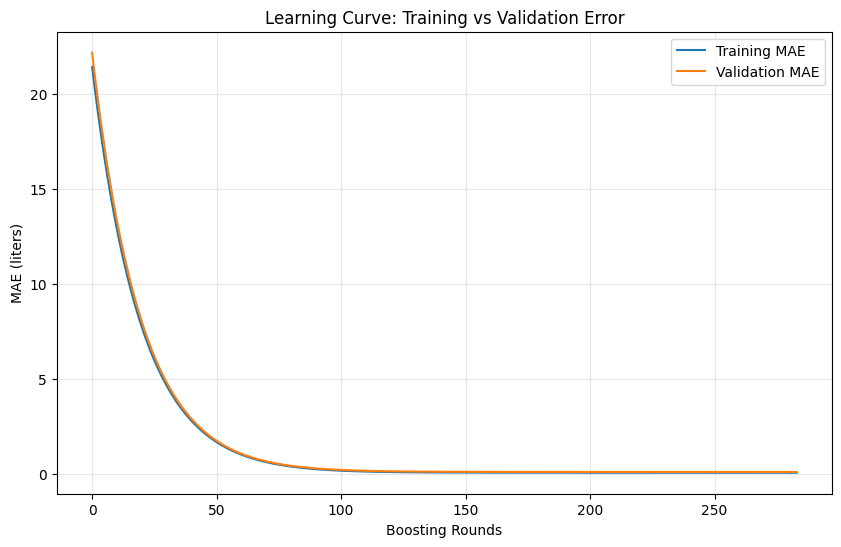


Overfitting Analysis:
Final Training MAE: 0.0613
Final Validation MAE: 0.1015
Performance Gap: 0.0402 ( < 0.1 - Good)

Tomato Water Need Prediction in Loamy Soil:
Predicted water needed: 12.54 liters


In [17]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error, explained_variance_score
import xgboost as xgb
from datetime import datetime, timedelta

# =====================
# 0. MAINTENANCE SYSTEM
# =====================
# Simple maintenance switch (False = normal operation)
MAINTENANCE_MODE = False

def system_maintenance_mode():
    """Check if maintenance mode is active"""
    return MAINTENANCE_MODE

def set_maintenance_mode(status: bool):
    """Manual control for maintenance (call this to override AI)"""
    global MAINTENANCE_MODE
    MAINTENANCE_MODE = status
    print(f"Maintenance mode {'ON' if status else 'OFF'}")

# ============================
# 1. SAFETY RULES FUNCTION (TOMATO FOCUS)
# ============================
def safe_irrigation(prediction, current_state):
    """Final safety overrides before irrigation for tomatoes in loamy soil"""
    max_moisture = 70  # Tomato-specific moisture threshold

    # 1. Soil saturation override
    if current_state['soil_moisture'] > max_moisture and prediction > 0:
        return 0

    # 2. Freezing protection - tomatoes more sensitive
    if current_state['temperature'] < 10:  # Increased from 5°C
        return 0

    # 3. Extreme heat protection - tomatoes more sensitive
    if current_state['temperature'] > 35:  # Lowered from 40°C
        return min(prediction, 0.3)  # More aggressive reduction

    # 4. Root temperature protection - tomato-specific range
    root_temp = current_state.get('root_temperature', current_state['temperature'])
    if root_temp > 30:  # Lowered threshold for tomatoes
        return prediction * 0.2
    if root_temp < 15:  # Increased threshold
        return 0

    return prediction

# ===========================================
# 1. DATA GENERATION WITH LIGHT & AC TRACKING (TOMATO OPTIMIZED)
# ===========================================
np.random.seed(42)
num_days = 45
base_time = datetime(2023, 6, 1)

timestamps = []
soil_moisture = []
temperature = []
humidity = []
light_intensity = []
ac_status = []  # 0=off, 1=cooling, 2=heating

# Initialize environmental states for tomatoes
prev_moisture = 65.0  # Start closer to ideal for tomatoes
prev_temp = 24.0       # Optimal temperature for tomatoes
prev_humidity = 60.0
ac_mode = 0

for minute in range(num_days * 24 * 60):
    current_time = base_time + timedelta(minutes=minute)
    hour = current_time.hour
    day_of_year = (current_time - datetime(current_time.year, 1, 1)).days

    # Seasonal variations - optimized for tomato growing season
    season_factor = 1 + 0.4 * np.sin(2 * np.pi * (day_of_year - 120) / 365)

    # Light intensity simulation (lux)
    if 6 <= hour <= 20:  # Daylight hours
        base_light = 1000 + 600 * np.sin(2 * np.pi * (hour - 6) / 24)
        light = np.clip(base_light + np.random.normal(0, 50), 600, 1600)
    else:  # Night hours
        light = np.clip(100 + np.random.normal(0, 20), 80, 150)

    # AC control logic
    temp_target = 24.0  # Tomato optimal temperature

    temp_error = prev_temp - temp_target

    # AC state transitions
    if abs(temp_error) > 1.0:
        if temp_error > 0:  # Too warm
            ac_mode = 1  # Cooling
        else:  # Too cold
            ac_mode = 2  # Heating
    else:
        ac_mode = 0  # Off

    # Regular readings every 7 minutes
    if minute % 7 == 0:
        take_reading = True
    else:
        # Conservative change detection
        moisture_change = abs(prev_moisture - np.random.normal(prev_moisture, 0.8))
        temp_change = abs(prev_temp - np.random.normal(prev_temp, 0.3))
        humidity_change = abs(prev_humidity - np.random.normal(prev_humidity, 1.2))
        take_reading = (moisture_change > 2) or (temp_change > 1) or (humidity_change > 4)

    if take_reading:
        # AC impact on environment
        if ac_mode == 1:  # Cooling
            temp_effect = -0.8 - np.random.normal(0, 0.2)
            humidity_effect = -0.6 - np.random.normal(0, 0.15)
        elif ac_mode == 2:  # Heating
            temp_effect = 0.7 + np.random.normal(0, 0.2)
            humidity_effect = -0.5 - np.random.normal(0, 0.15)
        else:
            temp_effect = 0
            humidity_effect = 0

        # Soil moisture dynamics - adjusted for loamy soil
        light_factor = light / 1000  # Scale light to 0-1.6 range
        # Slower moisture loss for loamy soil (0.07 vs 0.10)
        moisture = prev_moisture - (0.07 * season_factor * light_factor if 6 <= hour <= 20 else -0.03)
        moisture = np.clip(moisture + np.random.normal(0, 0.2), 20, 70)  # Tomato range

        # Temperature with AC impact
        base_temp = 22 + 6 * np.sin(2 * np.pi * (day_of_year - 120) / 365)  # Tomato range
        temp = base_temp + 8 * np.sin(2 * np.pi * (hour - 6) / 24) + temp_effect
        temp = np.clip(temp + np.random.normal(0, 0.4), 15, 38)

        # Humidity with AC impact
        base_hum = 65 - 15 * np.sin(2 * np.pi * (day_of_year - 120) / 365)  # Tomato optimal
        hum = base_hum - 25 * np.sin(2 * np.pi * (hour - 6) / 24) + humidity_effect
        hum = np.clip(hum + np.random.normal(0, 1.5), 35, 85)

        timestamps.append(current_time)
        soil_moisture.append(moisture)
        temperature.append(temp)
        humidity.append(hum)
        light_intensity.append(light)
        ac_status.append(ac_mode)

        prev_moisture = moisture
        prev_temp = temp
        prev_humidity = hum

df = pd.DataFrame({
    "timestamp": timestamps,
    "soil_moisture": soil_moisture,
    "temperature": temperature,
    "humidity": humidity,
    "light_intensity": light_intensity,
    "ac_status": ac_status
})

# ==========================
# 2. WATER NEED CALCULATION (TOMATO FOCUS)
# ==========================
def calculate_water_needed(row):
    moisture = row['soil_moisture']
    temp = row['temperature']
    hum = row['humidity']
    light = row['light_intensity']
    ac = row['ac_status']
    hour = row['timestamp'].hour
    month = row['timestamp'].month

    # TOMATO-SPECIFIC BASE NEED
    if moisture >= 70:  # Higher threshold for tomatoes
        base_need = 0
    else:
        base_need = (70 - moisture) * 0.9  # Increased coefficient

    # TEMPERATURE EFFECT - optimized for tomatoes
    temp_effect = 0
    if temp > 28:  # Higher stress above 28°C
        temp_effect = (temp - 28) * 0.9
    elif temp < 18:  # Reduced need below 18°C
        temp_effect = (18 - temp) * -0.4

    # HUMIDITY EFFECTS - narrower optimal range
    hum_effect = 0
    if hum < 60:
        hum_effect = (60 - hum) * 0.4
    elif hum > 80:
        hum_effect = (80 - hum) * 0.3

    # LIGHT EFFECT
    light_effect = max(0, light - 800) * 0.0009

    # AC EFFECT
    ac_effect = 0
    if ac == 1:  # Cooling
        ac_effect = -0.15 * (temp - 24) if temp > 24 else 0
    elif ac == 2:  # Heating
        ac_effect = 0.1 * (26 - temp) if temp < 26 else 0

    # TIME FACTOR
    time_factor = 1.6 if 6 <= hour <= 20 else 0.6  # Higher daytime factor

    # LOAMY SOIL FACTOR (retains moisture well)
    loamy_soil_factor = 0.8  # Reduce water needs by 20%

    total_need = (base_need + temp_effect + hum_effect + light_effect + ac_effect) * time_factor * loamy_soil_factor

    return max(0, total_need)

df['water_needed'] = df.apply(calculate_water_needed, axis=1)

# ======================
# 3. FEATURE ENGINEERING (TOMATO FOCUS)
# ======================
# First create time-based features
df['hour'] = df['timestamp'].dt.hour
df['month'] = df['timestamp'].dt.month
df['is_daylight'] = df['hour'].between(6, 20).astype(int)

# Enhanced Vapor Pressure Deficit (VPD) Calculation for tomatoes
def calculate_vpd(temperature, humidity):
    """Calculate true Vapor Pressure Deficit (kPa) for tomatoes"""
    svp = 0.61078 * np.exp(17.27 * temperature / (temperature + 237.3))
    avp = humidity / 100 * svp
    return (svp - avp) * 1.2  # Tomatoes are more sensitive to VPD

# Plant Water Stress Index (PWSI) for tomatoes
def calculate_pwsi(soil_moisture, vpd):
    """Tomato-specific water stress index"""
    return (1 - soil_moisture/70) * vpd * 0.88  # Higher sensitivity

# Root Zone Stability for tomatoes
def root_zone_stability(temp, humidity, moisture):
    """Tomato-specific root zone index"""
    # Tomato-specific optimal ranges
    temp_score = np.clip(1 - abs(temp - 24)/8, 0, 1)  # Optimal at 24°C
    humidity_score = np.clip(1 - abs(humidity - 70)/30, 0, 1)  # Optimal at 70%
    moisture_score = np.clip(moisture/70, 0, 1)  # 70% target
    return (temp_score * 0.5) + (humidity_score * 0.3) + (moisture_score * 0.2)

# Moisture-Temperature Interaction for tomatoes
def moisture_temp_interaction(moisture, temp):
    """Tomato-specific moisture adjustment"""
    if temp < 18:
        return moisture * 0.6
    elif temp > 28:
        return moisture * 1.6
    return moisture

# Apply VPD calculation
df['vapor_pressure_deficit'] = df.apply(lambda row: calculate_vpd(row['temperature'], row['humidity']), axis=1)

# Apply PWSI calculation
df['pwsi'] = df.apply(lambda row: calculate_pwsi(row['soil_moisture'], row['vapor_pressure_deficit']), axis=1)

# Moisture-Temperature Interaction
df['adjusted_soil_moisture'] = df.apply(
    lambda row: moisture_temp_interaction(row['soil_moisture'], row['temperature']),
    axis=1
)

# Root Zone Stability Index
df['root_zone_index'] = df.apply(
    lambda row: root_zone_stability(row['temperature'], row['humidity'], row['soil_moisture']),
    axis=1
)

# Soil Moisture Decay Modeling
df['moisture_decay_rate'] = df.groupby('hour')['soil_moisture'].transform(
    lambda x: -x.diff().mean()
).fillna(0)

# Environmental features
df['soil_moisture_deficit'] = 70 - df['adjusted_soil_moisture']  # Tomato-specific
df['light_moisture_interaction'] = df['light_intensity'] * df['soil_moisture_deficit']

# Convert AC status to binary indicators
df['ac_cooling'] = (df['ac_status'] == 1).astype(int)
df['ac_heating'] = (df['ac_status'] == 2).astype(int)

# Moisture trend features
df['moisture_trend_1h'] = df['adjusted_soil_moisture'].diff(periods=8).fillna(0)

# Light-based features
df['high_light'] = (df['light_intensity'] > 1000).astype(int)  # Higher threshold for tomatoes

# =====================
# 4. DATA PREPARATION
# =====================
# Use AC indicators instead of raw status
X = df.drop(["water_needed", "timestamp", "ac_status"], axis=1)
y = df["water_needed"]

# STORE FEATURE NAMES FOR DEPLOYMENT
FEATURE_NAMES = X.columns.tolist()

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Time-based split
split_idx = int(0.8 * len(df))
X_train, X_test = X_scaled[:split_idx], X_scaled[split_idx:]
y_train, y_test = y[:split_idx], y[split_idx:]

# ==============================================
# 5. MODEL TRAINING WITH OVERFITTING PREVENTION
# ==============================================
# Optimized parameters with regularization
params = {
    'n_estimators': 300,
    'max_depth': 6,
    'learning_rate': 0.05,
    'subsample': 0.8,
    'colsample_bytree': 0.9,
    'gamma': 0.1,
    'min_child_weight': 3,
    'reg_alpha': 0.1,  # L1 regularization
    'reg_lambda': 0.7,  # L2 regularization
    'objective': 'reg:squarederror',
    'eval_metric': 'mae',
    'early_stopping_rounds': 20,
    'tree_method': 'hist',
    'seed': 42
}

# Create DMatrix for efficient training
dtrain = xgb.DMatrix(X_train, label=y_train)
dtest = xgb.DMatrix(X_test, label=y_test)

# Create container for evaluation results
evals_result = {}

# Train with early stopping and validation monitoring
model = xgb.train(
    params,
    dtrain,
    num_boost_round=1000,
    evals=[(dtrain, 'train'), (dtest, 'eval')],
    evals_result=evals_result,
    verbose_eval=50,
    early_stopping_rounds=20
)

# ============================
# 6. PREDICTION AND EVALUATION
# ============================
y_pred = model.predict(dtest)

# Apply zero-water threshold (tomato-specific)
soil_mean = scaler.mean_[0]
soil_scale = scaler.scale_[0]
for i in range(len(y_pred)):
    soil = X_test[i, 0] * soil_scale + soil_mean
    if soil >= 70:  # Tomato-specific threshold
        y_pred[i] = 0

# Evaluation metrics
r2 = r2_score(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
evs = explained_variance_score(y_test, y_pred)

# Zero-water metrics
zero_mask = (y_test == 0)
false_positives = 0
false_negatives = 0

if zero_mask.any():
    zero_accuracy = np.mean(y_pred[zero_mask] < 0.5)
    false_positives = np.sum((y_pred >= 0.5) & (y_test == 0))
    false_negatives = np.sum((y_pred < 0.5) & (y_test > 0))
else:
    zero_accuracy = "N/A (no zero-water cases)"

print("\nModel Performance for Tomatoes in Loamy Soil:")
print(f"R² Score: {r2:.4f}")
print(f"Mean Absolute Error: {mae:.4f} liters")
print(f"Root Mean Squared Error: {rmse:.4f} liters")
print(f"Explained Variance: {evs:.4f}")
print(f"\nZero-Water Performance:")
print(f"Accuracy: {zero_accuracy}")
print(f"False Alarms: {false_positives}")
print(f"Missed Needs: {false_negatives}")

# ===================================
# 7. VISUALIZATION WITH SEABORN FIXES
# ===================================
plt.figure(figsize=(14, 10))
plt.suptitle("Tomato Plant Analysis in Loamy Soil", fontsize=16)

# Light vs Water Need
plt.subplot(2, 2, 1)
sns.scatterplot(x='light_intensity', y='water_needed', data=df,
                hue='is_daylight', palette='viridis', alpha=0.6)
plt.title('Light Intensity vs Water Need')
plt.xlabel('Light Intensity (lux)')
plt.ylabel('Water Needed (liters)')
plt.grid(alpha=0.2)

# AC Status vs Temperature
plt.subplot(2, 2, 2)
sns.boxplot(x='ac_status', y='temperature', hue='ac_status', data=df,
            palette='coolwarm', showfliers=False, legend=False)
plt.xticks([0, 1, 2], ['Off', 'Cooling', 'Heating'])
plt.title('AC Impact on Temperature')
plt.ylabel('Temperature (°C)')
plt.grid(alpha=0.2)

# AC Status vs Humidity
plt.subplot(2, 2, 3)
sns.boxplot(x='ac_status', y='humidity', hue='ac_status', data=df,
            palette='Blues', showfliers=False, legend=False)
plt.xticks([0, 1, 2], ['Off', 'Cooling', 'Heating'])
plt.title('AC Impact on Humidity')
plt.ylabel('Humidity (%)')
plt.grid(alpha=0.2)

# VPD vs PWSI
plt.subplot(2, 2, 4)
sns.scatterplot(x='vapor_pressure_deficit', y='pwsi', data=df,
                hue='root_zone_index', palette='coolwarm', alpha=0.7)
plt.title('Vapor Pressure Deficit vs Plant Water Stress')
plt.xlabel('VPD (kPa)')
plt.ylabel('Plant Water Stress Index')
plt.grid(alpha=0.2)

plt.tight_layout()
plt.subplots_adjust(top=0.92)
plt.savefig('tomato_stress_analysis.png', dpi=150)
plt.show()

# Prediction vs Actual
plt.figure(figsize=(10, 8))
plt.scatter(y_test, y_pred, alpha=0.6, color='blue', label='Predictions')
max_val = max(y_test.max(), y_pred.max())
plt.plot([0, max_val], [0, max_val], 'r--', label='Perfect Prediction')
plt.xlabel('Actual Water Needed (liters)')
plt.ylabel('Predicted Water Needed (liters)')
plt.title('Tomato Water Need Prediction Performance')
plt.grid(alpha=0.3)
plt.legend()
plt.savefig('tomato_prediction_performance.png', dpi=150)
plt.show()

# Feature importance
plt.figure(figsize=(12, 8))
xgb.plot_importance(model, max_num_features=12, importance_type='weight')
plt.title('Tomato Water Need Feature Importance')
plt.grid(alpha=0.3)
plt.savefig('tomato_feature_importance.png', dpi=150)
plt.show()

# =======================================
# 8. LEARNING CURVE TO DETECT OVERFITTING
# =======================================
# Extract evaluation results
train_mae = evals_result['train']['mae']
eval_mae = evals_result['eval']['mae']

# Plot learning curve
plt.figure(figsize=(10, 6))
plt.plot(train_mae, label='Training MAE')
plt.plot(eval_mae, label='Validation MAE')
plt.xlabel('Boosting Rounds')
plt.ylabel('MAE (liters)')
plt.title('Learning Curve: Training vs Validation Error')
plt.legend()
plt.grid(alpha=0.3)
plt.savefig('tomato_learning_curve.png', dpi=150)
plt.show()

# Overfitting analysis
final_train_mae = train_mae[-1]
final_eval_mae = eval_mae[-1]
mae_gap = abs(final_train_mae - final_eval_mae)

print("\nOverfitting Analysis:")
print(f"Final Training MAE: {final_train_mae:.4f}")
print(f"Final Validation MAE: {final_eval_mae:.4f}")
print(f"Performance Gap: {mae_gap:.4f} {'( < 0.1 - Good)' if mae_gap < 0.1 else '(⚠️ > 0.1 - Potential overfitting)'}")

# ======================
# 9. DEPLOYMENT FUNCTION
# ======================
def predict_water_need(current_readings, model=model, scaler=scaler):
    """
    Predict water needs for tomatoes in loamy soil.

    current_readings: dict with keys:
        'soil_moisture', 'temperature', 'humidity', 'light_intensity',
        'ac_status' (0=off, 1=cooling, 2=heating), 'hour' (0-23)
    Optional: 'root_temperature' for root zone monitoring
    """
    # 1. MAINTENANCE OVERRIDE
    if system_maintenance_mode():
        return 0.0

    # 2. Create feature vector
    features = pd.DataFrame([current_readings])

    # 3. Create AC state features
    features['ac_cooling'] = (features['ac_status'] == 1).astype(int)
    features['ac_heating'] = (features['ac_status'] == 2).astype(int)

    # 4. Extract scalar values
    soil_moisture_val = features['soil_moisture'].iloc[0]
    temperature_val = features['temperature'].iloc[0]
    humidity_val = features['humidity'].iloc[0]
    light_intensity_val = features['light_intensity'].iloc[0]
    hour_val = features['hour'].iloc[0]

    # 5. Calculate tomato-specific metrics
    adjusted_moisture = moisture_temp_interaction(soil_moisture_val, temperature_val)
    features['adjusted_soil_moisture'] = adjusted_moisture

    vpd_val = calculate_vpd(temperature_val, humidity_val)
    features['vapor_pressure_deficit'] = vpd_val

    pwsi_val = calculate_pwsi(adjusted_moisture, vpd_val)
    features['pwsi'] = pwsi_val

    root_zone_val = root_zone_stability(temperature_val, humidity_val, adjusted_moisture)
    features['root_zone_index'] = root_zone_val

    # 6. Add engineered features
    features['soil_moisture_deficit'] = 70 - adjusted_moisture
    features['light_moisture_interaction'] = light_intensity_val * features['soil_moisture_deficit']
    features['is_daylight'] = 1 if 6 <= hour_val <= 20 else 0

    # 7. Add month
    if 'month' not in features:
        features['month'] = datetime.now().month

    # 8. Set trend features to 0
    features['moisture_trend_1h'] = 0
    features['high_light'] = 1 if light_intensity_val > 1000 else 0

    # 9. Estimate moisture decay rate
    if 'moisture_decay_rate' not in features:
        decay_rate = 0.05 * temperature_val/25 * (100 - humidity_val)/50
        features['moisture_decay_rate'] = decay_rate

    # 10. Use EXACT feature names from training
    for feature in FEATURE_NAMES:
        if feature not in features:
            features[feature] = 0

    # Reorder features
    features = features[FEATURE_NAMES]

    # Scale features
    features_scaled = scaler.transform(features)

    # Create DMatrix
    dmatrix = xgb.DMatrix(features_scaled)

    # Predict
    prediction = model.predict(dmatrix)[0]

    # Apply zero-water rule
    if soil_moisture_val >= 70:
        prediction = 0

    # Apply safety rules
    prediction = safe_irrigation(prediction, current_readings)

    # Apply temporal adjustment
    def temporal_adjustment(hour, prediction):
        """Adjust watering based on time of day for tomatoes"""
        if 20 <= hour <= 24 or 0 <= hour <= 6:  # Night hours
            return prediction * 0.7
        elif 6 < hour <= 10:  # Morning hours
            return prediction * 1.4  # Higher morning factor for tomatoes
        return prediction

    prediction = temporal_adjustment(hour_val, prediction)

    return max(0, prediction)

# Example prediction for tomatoes
print("\nTomato Water Need Prediction in Loamy Soil:")
current_state = {
    'soil_moisture': 62.1,
    'temperature': 26.5,
    'humidity': 68.3,
    'light_intensity': 1100,
    'ac_status': 0,
    'hour': 11,
    'root_temperature': 24.8  # Important for tomatoes
}
water_needed = predict_water_need(current_state)
print(f"Predicted water needed: {water_needed:.2f} liters")